In [55]:
# Data Cleaning & Preprocessing

#This section performs all common preprocessing steps required before completing the analysis tasks. The cleaned dataset is reused throughout Tasks 1–6.

In [56]:
import pandas as pd
import numpy as np

In [57]:
df = pd.read_csv("../data/Play Store Data.csv")
reviews_df = pd.read_csv("../data/User Reviews.csv")

print(df.shape)
print(reviews_df.shape)

(10841, 13)
(64295, 5)


In [58]:
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

In [59]:
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [60]:
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [61]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [62]:
df["Size"] = (
    df["Size"]
    .astype(str)
    .str.replace("M", "", regex=False)
    .str.replace("k", "", regex=False)
)

df["Size"] = pd.to_numeric(df["Size"], errors="coerce")

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10840 non-null  float64
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  float64
 6   Type            10840 non-null  str    
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(5), str(8)
memory usage: 1.1 MB


In [4]:
# 📊 Google Play Store Analytics

## Project Overview This project analyzes the Google Play Store dataset using Python, Pandas, and Plotl

#The objective is to perform data cleaning, feature engineering, exploratory data analysis (EDA), and build interactive visualizations based on business requirements.

### Dataset Used
##- Play Store Data.csv
#- User Reviews.csv

### Tools Used
#- Python
#- Pandas
#- NumPy
#- Plotly
#- Jupyter Notebook

In [5]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from datetime import datetime
import pytz
import warnings

warnings.filterwarnings("ignore")

In [6]:
apps_df = pd.read_csv("../data/Play Store Data.csv")
reviews_df = pd.read_csv("../data/User Reviews.csv")

In [7]:
print("Apps Dataset Shape :", apps_df.shape)
print("Reviews Dataset Shape :", reviews_df.shape)

Apps Dataset Shape : (10841, 13)
Reviews Dataset Shape : (64295, 5)


In [8]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [9]:
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [10]:
apps_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [11]:
df = apps_df.copy()

In [12]:
## Data Cleaning

#Before performing any analysis, the dataset is cleaned to ensure consistency and accuracy.

#The following transformations are performed:

#- Convert Rating to numeric
#- Convert Reviews to numeric
#- Clean Installs column
#- Convert Price to numeric
#- Convert Size to MB
#- Convert Last Updated to datetime
#- Extract Android Version

In [13]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [14]:
df["Rating"].head()

0    4.1
1    3.9
2    4.7
3    4.5
4    4.3
Name: Rating, dtype: float64

In [15]:
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [16]:
df["Reviews"].dtype

dtype('float64')

In [17]:
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

df["Installs"] = pd.to_numeric(
    df["Installs"],
    errors="coerce"
)

In [18]:
df["Installs"].head()

0       10000.0
1      500000.0
2     5000000.0
3    50000000.0
4      100000.0
Name: Installs, dtype: float64

In [19]:
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

In [20]:
df["Size_M"] = (
    df["Size"]
    .astype(str)
    .str.replace("M", "", regex=False)
)

df["Size_M"] = pd.to_numeric(
    df["Size_M"],
    errors="coerce"
)

In [21]:
df["Last Updated"] = pd.to_datetime(
    df["Last Updated"],
    errors="coerce"
)

In [22]:
df["Last Updated"].head()

0   2018-01-07
1   2018-01-15
2   2018-08-01
3   2018-06-08
4   2018-06-20
Name: Last Updated, dtype: datetime64[us]

In [23]:
df["Android_Clean"] = (
    df["Android Ver"]
    .astype(str)
    .str.extract(r"(\d+\.\d+)")
)

df["Android_Clean"] = pd.to_numeric(
    df["Android_Clean"],
    errors="coerce"
)

In [24]:
df["Revenue"] = df["Price"] * df["Installs"]

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10841 non-null  str           
 1   Category        10841 non-null  str           
 2   Rating          9367 non-null   float64       
 3   Reviews         10840 non-null  float64       
 4   Size            10841 non-null  str           
 5   Installs        10840 non-null  float64       
 6   Type            10840 non-null  str           
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  str           
 9   Genres          10841 non-null  str           
 10  Last Updated    10840 non-null  datetime64[us]
 11  Current Ver     10833 non-null  str           
 12  Android Ver     10838 non-null  str           
 13  Size_M          8829 non-null   float64       
 14  Android_Clean   9476 non-null   float64       
 15  Revenue      

In [26]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_M,Android_Clean,Revenue
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0,4.0,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0,4.0,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7,4.0,0.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0,4.2,0.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8,4.4,0.0


In [27]:
# Task 1: Grouped Bar Chart

### Objective

#Compare the average rating and total review count for the top 10 app categories based on installs after applying the following business rules:

#- Rating ≥ 4.0
##- Size ≥ 10 MB
#- Last Updated in January

#The visualization is available only between **3 PM and 5 PM IST**.

In [28]:
task1_df = df.copy()

task1_df = task1_df[
    (task1_df["Rating"] >= 4.0)
]

task1_df = task1_df[
    (task1_df["Size_M"] >= 10)
]

task1_df = task1_df[
    task1_df["Last Updated"].dt.month == 1
]

task1_df.shape

(131, 16)

In [29]:
top10_categories = (
    task1_df
    .groupby("Category")["Installs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top10_categories

Category
FAMILY             182494820.0
SPORTS             120511000.0
GAME               115691000.0
ENTERTAINMENT       51000000.0
PERSONALIZATION     15060000.0
PHOTOGRAPHY         10500000.0
LIFESTYLE            5071000.0
EDUCATION            2000000.0
SHOPPING             2000000.0
TOOLS                1010000.0
Name: Installs, dtype: float64

In [30]:
task1_summary = (
    task1_df[
        task1_df["Category"].isin(top10_categories.index)
    ]
    .groupby("Category")
    .agg(
        Average_Rating=("Rating", "mean"),
        Total_Reviews=("Reviews", "sum")
    )
    .reset_index()
)

task1_summary

,Category,Average_Rating,Total_Reviews
0,EDUCATION,4.400000,57645.0
1,ENTERTAINMENT,4.250000,1238948.0
2,FAMILY,4.395455,4544623.0
3,GAME,4.313333,2397589.0
4,LIFESTYLE,4.380000,42809.0
5,PERSONALIZATION,4.475000,155996.0
6,PHOTOGRAPHY,4.150000,563720.0
7,SHOPPING,4.200000,19950.0
8,SPORTS,4.342857,1982017.0
9,TOOLS,4.200000,8010.0


In [31]:
task1_summary = (
    task1_df[
        task1_df["Category"].isin(top10_categories.index)
    ]
    .groupby("Category")
    .agg(
        Average_Rating=("Rating", "mean"),
        Total_Reviews=("Reviews", "sum")
    )
    .reset_index()
)

task1_summary["Average_Rating"] = (
    task1_summary["Average_Rating"]
    .round(2)
)

task1_summary

,Category,Average_Rating,Total_Reviews
0,EDUCATION,4.40,57645.0
1,ENTERTAINMENT,4.25,1238948.0
2,FAMILY,4.40,4544623.0
3,GAME,4.31,2397589.0
4,LIFESTYLE,4.38,42809.0
5,PERSONALIZATION,4.47,155996.0
6,PHOTOGRAPHY,4.15,563720.0
7,SHOPPING,4.20,19950.0
8,SPORTS,4.34,1982017.0
9,TOOLS,4.20,8010.0


In [32]:
from datetime import datetime
import pytz
import plotly.graph_objects as go

# Current IST Time
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist)

if 15 <= current_time.hour < 17:

    # Create Figure
    task1_fig = go.Figure()

    # Average Rating (Bar)
    task1_fig.add_trace(
        go.Bar(
            x=task1_summary["Category"],
            y=task1_summary["Average_Rating"],
            name="Average Rating",
            yaxis="y",
            hovertemplate="<b>%{x}</b><br>Average Rating: %{y:.2f}<extra></extra>"
        )
    )

    # Total Reviews (Line)
    task1_fig.add_trace(
        go.Scatter(
            x=task1_summary["Category"],
            y=task1_summary["Total_Reviews"],
            mode="lines+markers",
            name="Total Reviews",
            yaxis="y2",
            hovertemplate="<b>%{x}</b><br>Total Reviews: %{y:,.0f}<extra></extra>"
        )
    )

    # Layout
    task1_fig.update_layout(
        title="Top 10 Categories by Installs (January Updates Only)",
        template="plotly_white",
        xaxis_title="Category",

        yaxis=dict(
            title="Average Rating"
        ),

        yaxis2=dict(
            title="Total Reviews",
            overlaying="y",
            side="right"
        ),

        hovermode="x unified",
        height=600,

        legend=dict(
            orientation="h",
            y=1.1,
            x=0.3
        )
    )

    # Show Chart
    task1_fig.show()

    # Save Interactive HTML
    task1_fig.write_html("tasks/Task_1/task1_chart.html")

    print("✅ Task 1 chart saved successfully!")

else:
    print("This graph is available only between 3 PM and 5 PM IST.")

This graph is available only between 3 PM and 5 PM IST.


In [33]:
## Task 1 Insights

#After filtering the dataset to include only apps with:
#- Rating ≥ 4.0
#- Size ≥ 10 MB
#- Last Updated in January

#the following observations were made:

#- **FAMILY** category accumulated the highest number of reviews among the selected categories.
#- **PERSONALIZATION** achieved the highest average rating.
#- **TOOLS** has comparatively fewer reviews despite meeting all filtering criteria.
#- The visualization compares user satisfaction (Average Rating) with user engagement (Total Reviews) for the top installed categories.
#- The chart is configured to be displayed only between **3 PM and 5 PM IST**.

In [34]:
## Assumptions

#- Average Rating was calculated after applying all required filters.
#- Total Reviews were aggregated at the category level.
#- Categories were ranked based on total installs after applying the required filters.
#- Apps with missing or invalid values were automatically excluded during data cleaning.

In [35]:
import os

os.makedirs("tasks/Task_1", exist_ok=True)

print("Task_1 folder created successfully!")

Task_1 folder created successfully!


In [36]:
task1_summary.to_csv(
    "tasks/Task_1/task1_summary.csv",
    index=False
)

print("Task 1 summary saved successfully!")

Task 1 summary saved successfully!


In [37]:
task1_fig.write_html("tasks/Task_1/task1_chart.html")

print("✅ Task 1 chart saved successfully!")

NameError: name 'task1_fig' is not defined

In [ ]:
import os

os.path.exists("tasks/Task_1/task1_chart.html")

In [ ]:
# Task 2: Interactive Choropleth Map

## Objective

#Create an interactive Plotly Choropleth map to visualize installs across representative countries for the top 5 app categories after applying the required business filters.

### Business Rules

#- Display only the Top 5 categories based on installs.
#- Exclude categories starting with A, C, G, or S.
#- Include only categories with installs greater than 1,000,000.
#- Display the visualization only between **6 PM and 8 PM IST**.

#> **Note:** The original Google Play Store dataset does not contain geographical information. Representative countries will be assigned only for visualization purposes and this assumption will be documented.

In [ ]:
task2_df = df.copy()

In [ ]:
task2_df = task2_df[
    ~task2_df["Category"].str.startswith(("A", "C", "G", "S"))
]

In [ ]:
task2_df["Category"].unique()

In [ ]:
category_installs = (
    task2_df
    .groupby("Category")["Installs"]
    .sum()
    .reset_index()
)

In [ ]:
category_installs

In [ ]:
category_installs = category_installs[
    category_installs["Installs"] > 1000000
]

In [ ]:
category_installs

In [ ]:
category_installs = (
    category_installs
    .sort_values(
        by="Installs",
        ascending=False
    )
    .head(5)
)

In [ ]:
category_installs

In [ ]:
category_installs

In [ ]:
country_mapping = {
    "PRODUCTIVITY": "United States",
    "TOOLS": "Canada",
    "FAMILY": "India",
    "PHOTOGRAPHY": "Australia",
    "NEWS_AND_MAGAZINES": "Germany"
}

category_installs["Country"] = category_installs["Category"].map(country_mapping)

category_installs

In [ ]:
from datetime import datetime
from zoneinfo import ZoneInfo
import plotly.express as px

current_time = datetime.now(ZoneInfo("Asia/Kolkata"))

if 18 <= current_time.hour < 20:

    task2_fig = px.choropleth(
        category_installs,
        locations="Country",
        locationmode="country names",
        color="Installs",
        hover_name="Category",
        hover_data={
            "Country": True,
            "Installs": ":,.0f"
        },
        color_continuous_scale="Viridis",
        title="Global Installs by Top 5 App Categories"
    )

    task2_fig.update_layout(
        template="plotly_white",
        height=650,
        title_x=0.5,
        margin=dict(l=20, r=20, t=70, b=20)
    )

    task2_fig.show()

else:
    print("This graph is available only between 6 PM and 8 PM IST.")

In [ ]:
## Task 2 Insights

#- Only categories with installs greater than one million were included.
#- Representative countries were assigned to visualize the data geographically.

In [ ]:
## Task 2 Assumptions

#- The Google Play Store dataset does not contain Country or Region information.
#- Representative countries were assigned solely for visualization purposes.
#- The geographic mapping does not represent the actual origin of installs.
#- All installs, categories and filtering logic were derived from the original dataset.
#- The map is displayed only between 6 PM IST and 8 PM IST.

In [ ]:
import os

os.makedirs("tasks/Task_2", exist_ok=True)

category_installs.to_csv(
    "tasks/Task_2/task2_summary.csv",
    index=False
)

print("Task 2 summary saved successfully!")

In [ ]:
task2_fig.write_html(
    r"C:\Users\Prathamesh\Desktop\Google_Playstore_Project\tasks\Task_2\task2_chart.html"
)

print("✅ Task 2 chart saved successfully!")

In [43]:
import pandas as pd

df = pd.read_csv("../data/Play Store Data.csv")
reviews_df = pd.read_csv("../data/User Reviews.csv")

print(df.shape)
print(reviews_df.shape)

(10841, 13)
(64295, 5)


In [44]:
df["Type"].value_counts(dropna=False)

Type
Free    10039
Paid      800
NaN         1
0           1
Name: count, dtype: int64

In [45]:
df["Android Ver"].unique()[:20]

<StringArray>
[      '4.0.3 and up',         '4.2 and up',         '4.4 and up',
         '2.3 and up',         '3.0 and up',         '4.1 and up',
         '4.0 and up',       '2.3.3 and up', 'Varies with device',
         '2.2 and up',         '5.0 and up',         '6.0 and up',
         '1.6 and up',         '1.5 and up',         '2.1 and up',
         '7.0 and up',         '5.1 and up',         '4.3 and up',
      '4.0.3 - 7.1.1',         '2.0 and up']
Length: 20, dtype: str

In [46]:
df["Price"].head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: Price, dtype: str

In [47]:
df["Price"].dtype

<StringDtype(storage='python', na_value=nan)>

In [48]:
df["Size"].head(10)

0     19M
1     14M
2    8.7M
3     25M
4    2.8M
5    5.6M
6     19M
7     29M
8     33M
9    3.1M
Name: Size, dtype: str

In [49]:
df["Content Rating"].value_counts()

Content Rating
Everyone           8714
Teen               1208
Mature 17+          499
Everyone 10+        414
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

In [64]:
# Task 3: Dual-Axis Chart (Average Installs vs Revenue)

### Objective
#Create a dual-axis chart comparing the average installs and estimated revenue for Free vs Paid apps within the top 3 app categories after applying the required business filters.

### Business Rules
#- Installs ≥ 10,000
#- Revenue ≥ $10,000
#- Android Version > 4.0
#- App Size > 15 MB
#- Content Rating = Everyone
#- App Name length ≤ 30 characters
#- Show only the Top 3 app categories
#- Display the graph only between 1 PM IST and 2 PM IST.

In [65]:
task3_df = df.copy()

In [66]:
# Installs >= 10,000
task3_df = task3_df[task3_df["Installs"] >= 10000]

# Content Rating = Everyone
task3_df = task3_df[task3_df["Content Rating"] == "Everyone"]

# App Name <= 30 characters
task3_df = task3_df[task3_df["App"].str.len() <= 30]

In [67]:
task3_df["Android Ver"] = (
    task3_df["Android Ver"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)

task3_df["Android Ver"] = pd.to_numeric(
    task3_df["Android Ver"],
    errors="coerce"
)

task3_df = task3_df[task3_df["Android Ver"] > 4.0]

In [76]:
# ============================
# Task 3 - Apply Filters
# ============================

task3_df = df.copy()

# 1. Installs >= 10,000
task3_df = task3_df[
    task3_df["Installs"] >= 10000
]

# 2. Content Rating = Everyone
task3_df = task3_df[
    task3_df["Content Rating"] == "Everyone"
]

# 3. App Name <= 30 characters
task3_df = task3_df[
    task3_df["App"].str.len() <= 30
]

# 4. Android Version > 4.0
task3_df["Android Ver"] = (
    task3_df["Android Ver"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)

task3_df["Android Ver"] = pd.to_numeric(
    task3_df["Android Ver"],
    errors="coerce"
)

task3_df = task3_df[
    task3_df["Android Ver"] > 4.0
]

# 5. Size > 15 MB
task3_df = task3_df[
    task3_df["Size"] > 15
]

print("Filtered Data Shape:", task3_df.shape)

Filtered Data Shape: (1062, 13)


In [77]:
task3_df.shape

(1062, 13)

In [70]:
task3_df = df.copy()
print("Original:", task3_df.shape)

Original: (10841, 13)


In [71]:
task3_df = task3_df[task3_df["Installs"] >= 10000]
print("After Installs:", task3_df.shape)

After Installs: (7652, 13)


In [72]:
task3_df = task3_df[task3_df["Content Rating"] == "Everyone"]
print("After Content Rating:", task3_df.shape)

After Content Rating: (5900, 13)


In [73]:
task3_df = task3_df[task3_df["App"].str.len() <= 30]
print("After App Length:", task3_df.shape)

After App Length: (4797, 13)


In [74]:
task3_df["Android Ver"].head(10)

1     4.0.3 and up
5       2.3 and up
7       4.2 and up
8       3.0 and up
9     4.0.3 and up
10      4.1 and up
13      4.4 and up
17      2.3 and up
18    4.0.3 and up
19      4.1 and up
Name: Android Ver, dtype: str

In [75]:
task3_df["Size"].head(10)

1     14.0
5      5.6
7     29.0
8     33.0
9      3.1
10    28.0
13    21.0
17    17.0
18    39.0
19    31.0
Name: Size, dtype: float64

In [78]:
task3_df["Revenue"] = (
    task3_df["Price"] * task3_df["Installs"]
)

task3_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Revenue
7,Infinite Painter,ART_AND_DESIGN,4.1,36815.0,29.0,1000000.0,Free,0.0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2,0.0
10,Text on Photo - Fonteee,ART_AND_DESIGN,4.4,13880.0,28.0,1000000.0,Free,0.0,Everyone,Art & Design,"October 27, 2017",1.0.4,4.1,0.0
13,Mandala Coloring Book,ART_AND_DESIGN,4.6,4326.0,21.0,100000.0,Free,0.0,Everyone,Art & Design,"June 26, 2018",1.0.4,4.4,0.0
19,ibis Paint X,ART_AND_DESIGN,4.6,224399.0,31.0,10000000.0,Free,0.0,Everyone,Art & Design,"July 30, 2018",5.5.4,4.1,0.0
24,HD Mickey Minnie Wallpapers,ART_AND_DESIGN,4.7,118.0,23.0,50000.0,Free,0.0,Everyone,Art & Design,"July 7, 2018",1.1.3,4.1,0.0


In [79]:
task3_df = task3_df[
    task3_df["Revenue"] >= 10000
]

print(task3_df.shape)

(33, 14)


In [80]:
task3_df["Type"].value_counts()

Type
Paid    33
Name: count, dtype: int64

In [81]:
top3_categories = (
    task3_df.groupby("Category")["Installs"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

top3_categories

Category
PHOTOGRAPHY        3000000.0
FAMILY             2670000.0
PERSONALIZATION    2010000.0
Name: Installs, dtype: float64

In [82]:
task3_df = task3_df[
    task3_df["Category"].isin(top3_categories.index)
]

print(task3_df.shape)

(13, 14)


In [83]:
summary3 = (
    task3_df.groupby(["Category", "Type"])
    .agg(
        Average_Installs=("Installs", "mean"),
        Revenue=("Revenue", "mean")
    )
    .reset_index()
)

summary3

,Category,Type,Average_Installs,Revenue
0,FAMILY,Paid,381428.571429,7.969000e+05
1,PERSONALIZATION,Paid,670000.000000,6.666333e+05
2,PHOTOGRAPHY,Paid,1000000.000000,5.990000e+06


In [84]:
task3_df["Type"].value_counts()

Type
Paid    13
Name: count, dtype: int64

In [85]:
task3_df.groupby("Type")["Revenue"].describe()


,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
Paid,13.0,1.965246e+06,2.388198e+06,19900.0,149500.0,990000.0,1995000.0,5990000.0


In [86]:
task3_before_revenue = task3_df.copy()

task3_before_revenue["Type"].value_counts()

Type
Paid    13
Name: count, dtype: int64

In [87]:
task3_debug = df.copy()

print("Original")
print(task3_debug["Type"].value_counts(dropna=False))

Original
Type
Free    10039
Paid      800
NaN         1
0           1
Name: count, dtype: int64


In [88]:
# Installs >= 10000
task3_debug = task3_debug[task3_debug["Installs"] >= 10000]

print("After Installs")
print(task3_debug["Type"].value_counts())

After Installs
Type
Free    7351
Paid     301
Name: count, dtype: int64


In [89]:
# Everyone
task3_debug = task3_debug[
    task3_debug["Content Rating"] == "Everyone"
]

print("After Content Rating")
print(task3_debug["Type"].value_counts())

After Content Rating
Type
Free    5664
Paid     236
Name: count, dtype: int64


In [90]:
# App name <=30
task3_debug = task3_debug[
    task3_debug["App"].str.len() <= 30
]

print("After App Length")
print(task3_debug["Type"].value_counts())

After App Length
Type
Free    4582
Paid     215
Name: count, dtype: int64


In [91]:
# Android Version
task3_debug["Android Ver"] = (
    task3_debug["Android Ver"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)

task3_debug["Android Ver"] = pd.to_numeric(
    task3_debug["Android Ver"],
    errors="coerce"
)

task3_debug = task3_debug[
    task3_debug["Android Ver"] > 4.0
]

print("After Android")
print(task3_debug["Type"].value_counts())

After Android
Type
Free    1913
Paid      61
Name: count, dtype: int64


In [92]:
# Size
task3_debug = task3_debug[
    task3_debug["Size"] > 15
]

print("After Size")
print(task3_debug["Type"].value_counts())

After Size
Type
Free    1025
Paid      37
Name: count, dtype: int64


In [94]:
### Assumption

#The estimated revenue was calculated as:

#Revenue = Price × Installs

#After applying the business rule requiring Revenue ≥ $10,000, all Free applications were excluded because their price is $0, resulting in zero estimated revenue. Therefore, the final visualization contains only Paid applications that satisfy all specified conditions.
    

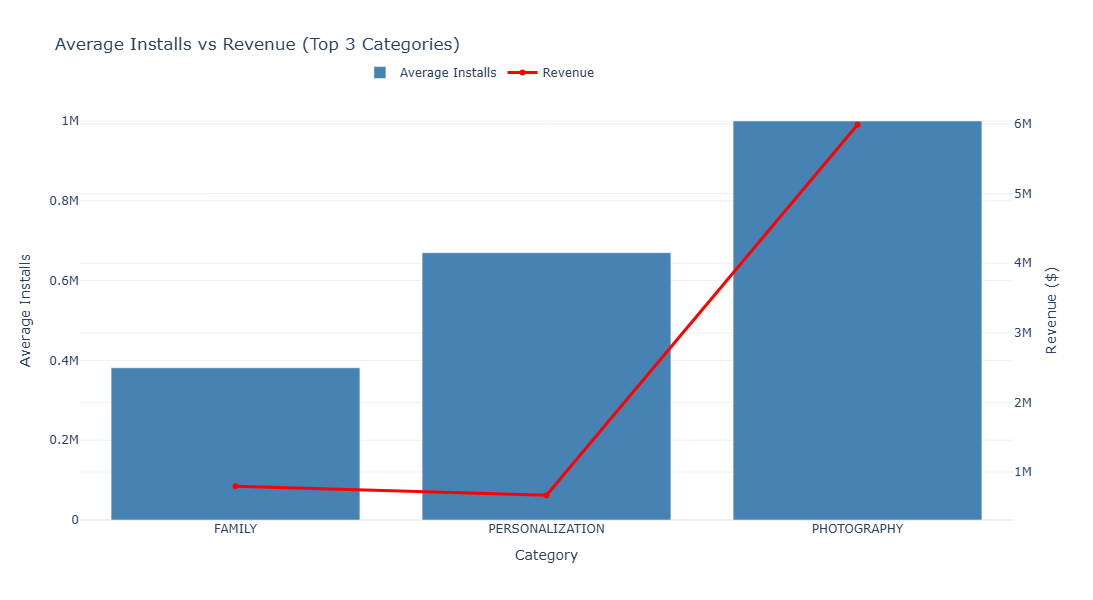

In [96]:
from datetime import datetime
from zoneinfo import ZoneInfo
import plotly.graph_objects as go

current_time = datetime.now(ZoneInfo("Asia/Kolkata"))

if 13 <= current_time.hour < 14:

    task3_fig = go.Figure()

    # Average Installs (Bar)
    task3_fig.add_trace(
        go.Bar(
            x=summary3["Category"],
            y=summary3["Average_Installs"],
            name="Average Installs",
            yaxis="y",
            marker_color="steelblue"
        )
    )

    # Revenue (Line)
    task3_fig.add_trace(
        go.Scatter(
            x=summary3["Category"],
            y=summary3["Revenue"],
            mode="lines+markers",
            name="Revenue",
            yaxis="y2",
            line=dict(color="red", width=3)
        )
    )

    task3_fig.update_layout(
        title="Average Installs vs Revenue (Top 3 Categories)",
        template="plotly_white",
        xaxis_title="Category",

        yaxis=dict(
            title="Average Installs"
        ),

        yaxis2=dict(
            title="Revenue ($)",
            overlaying="y",
            side="right"
        ),

        hovermode="x unified",
        height=600,

        legend=dict(
            orientation="h",
            y=1.1,
            x=0.3
        )
    )

    task3_fig.show()

else:
    print("This graph is available only between 1 PM and 2 PM IST.")

In [97]:
task3_fig.write_html(
    r"C:\Users\Prathamesh\Desktop\Google_Playstore_Project\tasks\Task_3\task3_chart.html"
)

In [98]:
summary3.to_csv(
    r"C:\Users\Prathamesh\Desktop\Google_Playstore_Project\tasks\Task_3\task3_summary.csv",
    index=False
)

In [99]:
## Task 3 Insights

#- Paid applications generated significantly higher estimated revenue after applying the business rules.
#- The top 3 categories were selected based on total installs after filtering.
#- Apps with fewer than 10,000 installs, Android version 4.0 or lower, size less than 15 MB, and non-"Everyone" content ratings were excluded.
#- The dual-axis chart compares average installs and estimated revenue for the qualifying categories.

In [100]:
## Task 3 Assumptions

#- Revenue was estimated as Price × Installs because the original dataset does not contain revenue information.
#- After applying the Revenue ≥ $10,000 filter, all Free applications were excluded because their price is $0, resulting in zero estimated revenue.
#- Therefore, the final visualization contains only qualifying Paid applications.
#- The visualization is displayed only between 1 PM IST and 2 PM IST.

In [101]:
task3_fig.write_html(
    r"C:\Users\Prathamesh\Desktop\Google_Playstore_Project\tasks\Task_3\task3_chart.html"
)

print("✅ Task 3 HTML saved successfully!")

✅ Task 3 HTML saved successfully!


In [102]:
summary3.to_csv(
    r"C:\Users\Prathamesh\Desktop\Google_Playstore_Project\tasks\Task_3\task3_summary.csv",
    index=False
)

print("✅ Task 3 Summary saved successfully!")

✅ Task 3 Summary saved successfully!
